In [74]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings("ignore")


In [75]:
from sklearn.datasets import make_classification


In [76]:
x,y = make_classification(n_samples = 1000,n_features=3,n_classes=2,n_redundant=0)  # n_redundant means features that are generated as random linear combinations of the informative features. These features do not add any new information to the dataset and are often used to test the robustness of machine learning algorithms.

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
x_train , x_test , y_train , y_test , = train_test_split(x,y,test_size=0.20,random_state=1)

In [79]:
from sklearn.neighbors import KNeighborsClassifier

In [80]:
kn = KNeighborsClassifier()

In [81]:
kn

KNeighborsClassifier()

In [82]:
kn.fit(x_train,y_train)

KNeighborsClassifier()

In [83]:
y_pred = kn.predict(x_test)

In [84]:
from sklearn.metrics import classification_report,confusion_matrix

In [85]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        98
           1       0.87      0.79      0.83       102

    accuracy                           0.83       200
   macro avg       0.84      0.84      0.83       200
weighted avg       0.84      0.83      0.83       200



In [86]:
confusion_matrix(y_test,y_pred)

array([[86, 12],
       [21, 81]])

In [87]:
import seaborn as sns

Text(0.5, 1.0, 'confusion matrix')

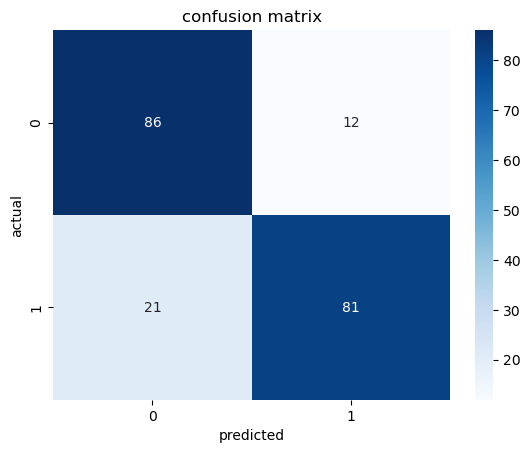

In [88]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap="Blues",fmt="d")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")

In [89]:
from sklearn.model_selection import GridSearchCV

In [90]:
params = {"n_neighbors":[1,2,3,4,4,5,6,6,7,8,9,10],
          "weights":["uniform","distance"],
          "algorithm":["auto","ball_tree","kd_tree","brute"],
          "leaf_size":[10,20,30,40,50],}

In [91]:
knn = KNeighborsClassifier()

In [92]:
grid = GridSearchCV(estimator=knn,param_grid=params,cv=5)   # verbous means it will show the progress of the grid search in the console.

In [93]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'leaf_size': [10, 20, 30, 40, 50],
                         'n_neighbors': [1, 2, 3, 4, 4, 5, 6, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']})

In [95]:
grid.best_params_

{'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 7, 'weights': 'uniform'}

In [97]:
final = grid.best_estimator_

In [100]:
y_pred = final.predict(x_test)

In [103]:
from sklearn.datasets import make_regression

In [107]:
x,y = make_regression(n_samples=1000,n_features=2,noise=10)

In [110]:
from sklearn.model_selection import train_test_split

In [112]:
x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size=0.20,random_state=1)

In [114]:
from sklearn.neighbors import KNeighborsRegressor

In [116]:
knr = KNeighborsRegressor()

In [118]:
knr.fit(x_train,y_train)

KNeighborsRegressor()

In [121]:
y_pred = knr.predict(x_test)

In [126]:
from sklearn.metrics import mean_squared_error      # in reg we have to use mean_squared_error or r2_score and in classification we have to use confusion_matrix or classification_report.

In [128]:
mean_squared_error(y_pred , y_test)

143.88833018994714

In [129]:
# with hypermeter tuning

In [132]:
from sklearn.model_selection import GridSearchCV

In [138]:
params = {"n_neighbors":[1,2,3,4,5,6,7,8,9,10],"weights":["uniform","distance"],"algorithm":["auto","ball_tree","kd_tree","brute"],"leaf_size":[10,20,30,40,50]}

In [139]:
grid = GridSearchCV(estimator=knr,param_grid=params,cv=5,verbose=3)

In [140]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV 1/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.960 total time=   0.0s
[CV 2/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.961 total time=   0.0s
[CV 3/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.966 total time=   0.0s
[CV 4/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.966 total time=   0.0s
[CV 5/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.958 total time=   0.0s
[CV 1/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, score=0.960 total time=   0.0s
[CV 2/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, score=0.961 total time=   0.0s
[CV 3/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, score=0.966 total time=   0.0s
[CV 4/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, 

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'leaf_size': [10, 20, 30, 40, 50],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']},
             verbose=3)

In [142]:
grid.best_params_

{'algorithm': 'brute',
 'leaf_size': 10,
 'n_neighbors': 6,
 'weights': 'distance'}

In [144]:
grid.best_score_

np.float64(0.9752114129127815)

In [146]:
final = grid.best_estimator_

In [149]:
y_pred = final.predict(x_test)

In [151]:
mean_squared_error(y_pred,y_test)

134.40658849384974